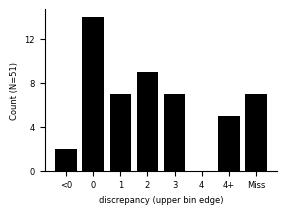

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

labels = ["<0", "0", "1", "2", "3", "4", "4+", "Miss"]
counts = [2, 14, 7, 9, 7, 0, 5, 7]      # <-- your numbers
N = sum(counts)


plt.rcParams["font.size"] = 6

fig, ax = plt.subplots(figsize=(3.0, 2.1))
ax.bar(labels, counts, color="black", edgecolor="none")
ax.set_xlabel("discrepancy (upper bin edge)")
ax.set_ylabel(f"Count (N={N})")

ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
ax.spines[["top", "right"]].set_visible(False)
fig.savefig("Tracking_gem_mask.pdf", bbox_inches="tight")

In [1]:
\begin{table}[t]
\centering
\caption{Detection counts per person across 11 runs, compared against ground truth.}
\label{tab:person_runs}
\resizebox{\textwidth}{!}{%
\begin{tabular}{c c *{11}{c} c c c c}
\toprule
Person & Real & R1 & R2 & R3 & R4 & R5 & R6 & R7 & R8 & R9 & R10 & R11 & Average & \% correct & Runs $\geq$1 hit & \% correct \\
\midrule
1    & 4 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3.0  & 75\%  & 11 & 100\% \\
2    & 3 & 1 & 1 & 1 & 1 & 1 & 1 & 2 & 1 & 1 & 2 & 1 & 1.2  & 39\%  & 11 & 100\% \\
3    & 3 & 2 & 1 & 1 & 3 & 2 & 1 & 3 & 3 & 1 & 3 & 3 & 2.1  & 70\%  & 11 & 100\% \\
4    & 4 & 2 & 1 & 2 & 3 & 3 & 1 & 3 & 4 & 3 & 1 & 2 & 2.3  & 57\%  & 11 & 100\% \\
5    & 2 & 2 & 3 & 3 & 2 & 2 & 2 & 1 & 2 & 2 & 2 & 1 & 2.0  & 100\% & 11 & 100\% \\
6    & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1.0  & 100\% & 11 & 100\% \\
7    & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 0 & 1 & 1 & 0.9  & 91\%  & 10 & 91\%  \\
8    & 1 & 0 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 0 & 0 & 0 & 0.4  & 36\%  & 4  & 36\%  \\
\midrule
None & 5 & 12& 13& 12& 10& 10& 13& 10& 7 & 12& 13& 11& 11.2 & 224\% & -- & --   \\
\bottomrule
\end{tabular}%
}
\end{table}


SyntaxError: unexpected character after line continuation character (1486249215.py, line 1)

In [11]:
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve().parents[1]  # src/Experiments -> project root

files = [
    project_root / "Data/07_Tropea_cafe/080_Experiments/100m_gps_v3/100m_gps_v3_results.csv",
    project_root / "Data/01_walk/080_Experiments/sweep_inferity/sweep_inferity_results.csv",
    project_root / "Data/01_walk/080_Experiments/sweeps_short_inferity/sweeps_short_inferity_results.csv",
]

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df


,rmse,mean dist,correspondences,cam poses (n),trajectory length (m),spatial_extent,rmse cm/m,runtime (min),n_frames,recon_interframe_interval,technique,cam_poses
0,25.081670,17.201864,7,25,166.596378,47.728987,15.055351,0.351512,25,280,CUT3R,25
1,29.850884,25.556398,7,25,166.596378,47.728987,17.918087,0.312374,25,280,CUT3R_Revisit,25
2,4.821915,4.603617,7,25,166.596378,47.728987,2.894370,0.714819,25,280,lingbot-map,25
3,20.817730,15.309364,7,25,166.596378,47.728987,12.495908,2.013344,25,280,MegaSaM,25
4,14.027455,12.929256,7,25,166.596378,47.728987,8.420024,0.453451,25,280,VGGT,25
...,...,...,...,...,...,...,...,...,...,...,...,...
181,0.972012,0.818100,26,273,102.578517,27.261005,0.947578,13.790497,273,9,MegaSaM,275
182,6.426026,5.346714,26,273,102.578517,27.261005,6.264495,1.206999,273,9,CUT3R,300
183,26.393312,23.454321,26,273,102.578517,27.261005,25.729863,1.942909,273,9,CUT3R_Revisit,300
184,3.093909,2.646202,26,273,102.578517,27.261005,3.016137,1.500880,273,9,lingbot-map,300


In [24]:
out_dir = project_root/"Data"/"FIGS"

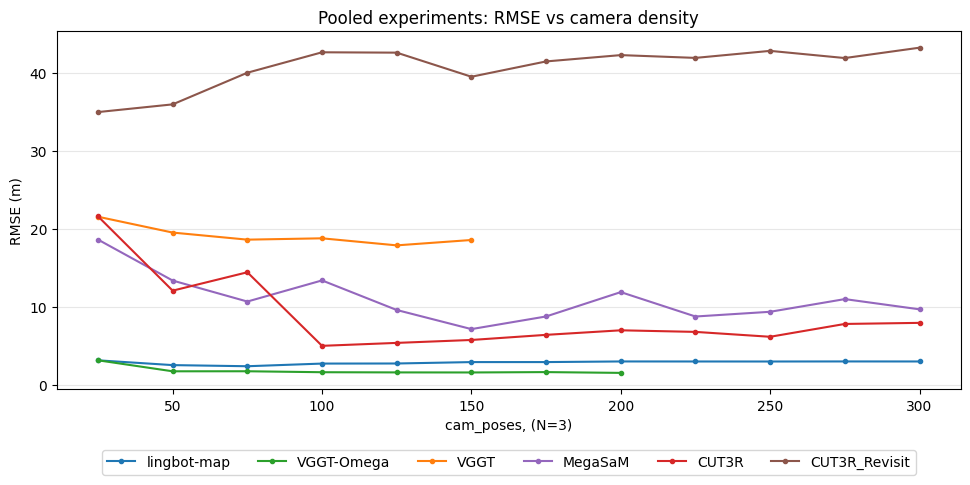

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

runs = [
    ("07_Tropea_cafe", "100m_gps_v3"),
    ("01_walk", "sweep_inferity"),
    ("01_walk", "sweeps_short_inferity"),
]

dfs = []
for case, exp in runs:
    set_case(case)
    results_path = case_dir() / "080_Experiments" / exp / f"{exp}_results.csv"
    edf = pd.read_csv(results_path)
    dfs.append(edf)
df = pd.concat(dfs, ignore_index=True)

pooled = df.groupby(["technique", "cam_poses"], as_index=False)[["rmse", "mean dist"]].mean()

TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega", "VGGT", "MegaSaM", "CUT3R", "CUT3R_Revisit"]
#TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],
}

techniques = [t for t in TECHNIQUE_ORDER if t in pooled["technique"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = pooled[pooled["technique"] == technique].sort_values("cam_poses")
    ax.plot(sub["cam_poses"], sub["rmse"], marker="o", markersize=3, label=technique, color=COLOR_MAP.get(technique))



ax.set_xlabel("cam_poses, (N=3)")
ax.set_ylabel("RMSE (m)")
ax.set_title("Pooled experiments: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "pooled_RMSE_no stdev_vggt0_vs_ling.pdf", format="pdf", bbox_inches="tight")


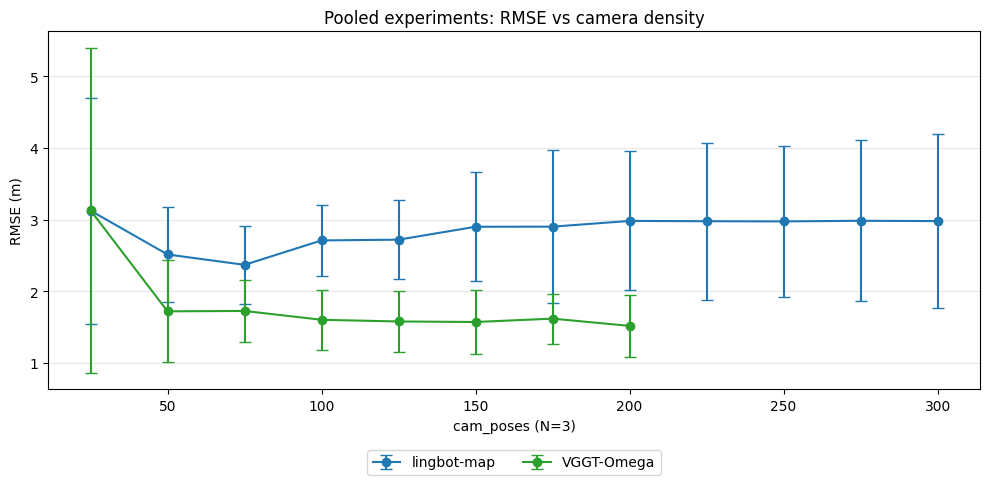

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

runs = [
    ("07_Tropea_cafe", "100m_gps_v3"),
    ("01_walk", "sweep_inferity"),
    ("01_walk", "sweeps_short_inferity"),
]

dfs = []
for case, exp in runs:
    set_case(case)
    results_path = case_dir() / "080_Experiments" / exp / f"{exp}_results.csv"
    edf = pd.read_csv(results_path)
    dfs.append(edf)
df = pd.concat(dfs, ignore_index=True)

pooled = df.groupby(["technique", "cam_poses"])["rmse"].agg(["mean", "std"]).reset_index()

#TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega", "VGGT", "MegaSaM", "CUT3R", "CUT3R_Revisit"]
TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],
}

techniques = [t for t in TECHNIQUE_ORDER if t in pooled["technique"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = pooled[pooled["technique"] == technique].sort_values("cam_poses")
    ax.errorbar(
        sub["cam_poses"], sub["mean"], yerr=sub["std"],
        marker="o", markersize=6, capsize=4, label=technique, color=COLOR_MAP.get(technique),
    )

ax.set_xlabel("cam_poses (N=3)")
ax.set_ylabel("RMSE (m)")

ax.set_title("Pooled experiments: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "pooled_RMSE_lingvggto.pdf", format="pdf", bbox_inches="tight")


In [ ]:
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve().parents[1]  # src/Experiments -> project root
out_dir = project_root / "Data" / "FIGS"

# Confidence percentiles, project-wide -- every case/recon-type/experiment/experiment_tag
# combination in Data/, produced by Thr3D/G_confidence_miner.py (re-run
# `python -m Thr3D.G_confidence_miner` from src/ to refresh). Not tied to any one
# case/run, unlike the sweep-results CSVs above -- see that module's docstring for what
# each recon type's confidence field actually is (and which ones don't have one at all).
conf_df = pd.read_csv(project_root / "Data" / "confidence_report.csv")
scored = conf_df[conf_df["confidence_available"]]
pct_cols = [c for c in conf_df.columns if c.startswith("p") and c[1:].isdigit()]
scored.groupby("recon_type")[["mean", *pct_cols]].describe()

In [ ]:
import matplotlib.pyplot as plt

# Boxplot per recon_type, built from each run's own percentile columns (no raw samples
# are stored in the CSV -- see miner docstring) rather than a real per-sample boxplot:
# whiskers = mean(p1)/mean(p99) across runs of that type, box = mean(p25)/mean(p50)/mean(p75).
# Same tab10 colour convention as the RMSE charts above.
RECON_TYPE_ORDER = ["CUT3R", "CUT3R_Revisit", "lingbot-map", "VGGT-O", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
CONF_COLOR_MAP = {
    "lingbot-map":   tab10[0],
    "VGGT":          tab10[1],
    "VGGT-O":        tab10[2],
    "CUT3R":         tab10[3],
    "MegaSaM":       tab10[4],
    "CUT3R_Revisit": tab10[5],
}

types_present = [t for t in RECON_TYPE_ORDER if t in scored["recon_type"].unique()]
stats = []
for t in types_present:
    sub = scored[scored["recon_type"] == t]
    stats.append({
        "label": f"{t}\n(n={len(sub)})",
        "whislo": sub["p1"].mean(),
        "q1":     sub["p25"].mean(),
        "med":    sub["p50"].mean(),
        "q3":     sub["p75"].mean(),
        "whishi": sub["p99"].mean(),
        "fliers": [],
    })

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.bxp(stats, showfliers=False, patch_artist=True, widths=0.5)
for patch, t in zip(bp["boxes"], types_present):
    patch.set_facecolor(CONF_COLOR_MAP.get(t, "gray"))
    patch.set_alpha(0.7)

ax.set_ylabel("confidence")
ax.set_title("Confidence percentiles by recon type (project-wide, all cases/experiments)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "confidence_by_recon_type.pdf", format="pdf", bbox_inches="tight")